In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#  Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load dataset
df = pd.read_csv('../data/raw/customer_transactions.csv')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

print("DATASET LOADED SUCCESSFULLY!")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Date Range: {df['TransactionDate'].min().date()} to {df['TransactionDate'].max().date()}")
print(f"Total Revenue: ₹{df['Amount'].sum():,.2f}")
print(f"Average Transaction: ₹{df['Amount'].mean():,.2f}")

print("\n\nColumn Information:")
print("-" * 80)
print(df.dtypes)

print("\n\nFirst 5 Transactions:")
print("-" * 80)
print(df.head())

print("\n\nBasic Statistics:")
print("-" * 80)
print(df.describe())

DATASET LOADED SUCCESSFULLY!

Dataset Shape: (397884, 7)
Total Transactions: 397,884
Unique Customers: 4,338
Date Range: 2010-12-01 to 2011-12-09
Total Revenue: ₹8,911,407.90
Average Transaction: ₹22.40


Column Information:
--------------------------------------------------------------------------------
InvoiceNo                   int64
CustomerID                  int64
TransactionDate    datetime64[us]
Quantity                    int64
UnitPrice                 float64
Amount                    float64
Country                       str
dtype: object


First 5 Transactions:
--------------------------------------------------------------------------------
   InvoiceNo  CustomerID     TransactionDate  Quantity  UnitPrice  Amount  \
0     536365       17850 2010-12-01 08:26:00         6       2.55   15.30   
1     536365       17850 2010-12-01 08:26:00         6       3.39   20.34   
2     536365       17850 2010-12-01 08:26:00         8       2.75   22.00   
3     536365       17850 2010

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Load cleaned CSV
df = pd.read_csv('../data/raw/customer_transactions.csv')

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

print("DATASET LOADED SUCCESSFULLY!")
print("=" * 80)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Date Range: {df['TransactionDate'].min().date()} to {df['TransactionDate'].max().date()}")
print(f"Total Revenue: ₹{df['Amount'].sum():,.2f}")
print(f"Average Transaction: ₹{df['Amount'].mean():,.2f}")

print("\nColumn Information:")
print("-" * 80)
print(df.dtypes)

print("\nFirst 5 Transactions:")
print("-" * 80)
print(df.head())

print("\nBasic Statistics:")
print("-" * 80)
print(df.describe())

DATASET LOADED SUCCESSFULLY!

Dataset Shape: (397884, 7)
Total Transactions: 397,884
Unique Customers: 4,338
Date Range: 2010-12-01 to 2011-12-09
Total Revenue: ₹8,911,407.90
Average Transaction: ₹22.40

Column Information:
--------------------------------------------------------------------------------
InvoiceNo                   int64
CustomerID                  int64
TransactionDate    datetime64[us]
Quantity                    int64
UnitPrice                 float64
Amount                    float64
Country                       str
dtype: object

First 5 Transactions:
--------------------------------------------------------------------------------
   InvoiceNo  CustomerID     TransactionDate  Quantity  UnitPrice  Amount  \
0     536365       17850 2010-12-01 08:26:00         6       2.55   15.30   
1     536365       17850 2010-12-01 08:26:00         6       3.39   20.34   
2     536365       17850 2010-12-01 08:26:00         8       2.75   22.00   
3     536365       17850 2010-1

## DATA OVERVIEW

- **Total Transactions:** 25,000  
- **Unique Customers:** 4,970  
- **Total Revenue:** ₹27.6 Lakh  
- **Data Coverage:** ~10 months  
- **Average Transaction Value:** ₹110  


## RFM Analysis

In [6]:


# Set analysis date (last transaction date + 1 day)
analysis_date = df['TransactionDate'].max() + pd.Timedelta(days=1)
print(f"\nAnalysis Date: {analysis_date.date()}")
print("-" * 80)

# Calculate RFM metrics for each customer
rfm = df.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'Amount': ['count', 'sum']                                     # Frequency & Monetary
})

# Flatten column names
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print("\nRFM Metrics Calculated:")
print("-" * 80)
print(f"Total Customers: {len(rfm):,}")
print(f"\nRecency (Days since last purchase):")
print(f"  - Min: {rfm['Recency'].min()} days (just purchased)")
print(f"  - Max: {rfm['Recency'].max()} days (long time ago)")
print(f"  - Average: {rfm['Recency'].mean():.1f} days")

print(f"\nFrequency (Number of purchases):")
print(f"  - Min: {rfm['Frequency'].min()} purchase")
print(f"  - Max: {rfm['Frequency'].max()} purchases")
print(f"  - Average: {rfm['Frequency'].mean():.1f} purchases")

print(f"\nMonetary (Total amount spent):")
print(f"  - Min: ₹{rfm['Monetary'].min():,.2f}")
print(f"  - Max: ₹{rfm['Monetary'].max():,.2f}")
print(f"  - Average: ₹{rfm['Monetary'].mean():,.2f}")

print("\n\nSample RFM Data:")
print("-" * 80)
print(rfm.head(10))

print("\n\nRFM Distribution Statistics:")
print("-" * 80)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


Analysis Date: 2011-12-10
--------------------------------------------------------------------------------

RFM Metrics Calculated:
--------------------------------------------------------------------------------
Total Customers: 4,338

Recency (Days since last purchase):
  - Min: 1 days (just purchased)
  - Max: 374 days (long time ago)
  - Average: 92.5 days

Frequency (Number of purchases):
  - Min: 1 purchase
  - Max: 7847 purchases
  - Average: 91.7 purchases

Monetary (Total amount spent):
  - Min: ₹3.75
  - Max: ₹280,206.02
  - Average: ₹2,054.27


Sample RFM Data:
--------------------------------------------------------------------------------
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2        182   4310.00
2       12348       75         31   1797.24
3       12349       19         73   1757.55
4       12350      310         17    334.40
5       12352       36         85   2506.04
6       12353      204         

## RFM Scoring

In [7]:
# Create RFM scores using quartiles
# Recency: Lower is better (recent purchase = high score)
# Frequency: Higher is better (more purchases = high score)  
# Monetary: Higher is better (more spending = high score)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Convert to int
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Calculate RFM Score (combine all three)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Create RFM Segment String
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("\nRFM Scores Created:")
print("-" * 80)
print("Score Range: 1 (Worst) to 5 (Best) for each metric")
print("\nRecency Score: 5 = Recent purchase, 1 = Long time ago")
print("Frequency Score: 5 = Many purchases, 1 = Few purchases")
print("Monetary Score: 5 = High spender, 1 = Low spender")
print("RFM Score: Sum of R+F+M (Range: 3 to 15)")
print("\n\nRFM Score Distribution:")
print("-" * 80)
print(rfm['RFM_Score'].value_counts().sort_index())

print("\n\nSample Scored Customers:")
print("-" * 80)
print(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

# Identify best and worst customers
best_customers = rfm.nlargest(10, 'RFM_Score')[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']]
worst_customers = rfm.nsmallest(10, 'RFM_Score')[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Score']]

print("\n\nTOP 10 BEST CUSTOMERS (Highest RFM Score):")
print("-" * 80)
print(best_customers.to_string(index=False))

print("\n\nTOP 10 WORST CUSTOMERS (Lowest RFM Score):")
print("-" * 80)
print(worst_customers.to_string(index=False))


RFM Scores Created:
--------------------------------------------------------------------------------
Score Range: 1 (Worst) to 5 (Best) for each metric

Recency Score: 5 = Recent purchase, 1 = Long time ago
Frequency Score: 5 = Many purchases, 1 = Few purchases
Monetary Score: 5 = High spender, 1 = Low spender
RFM Score: Sum of R+F+M (Range: 3 to 15)


RFM Score Distribution:
--------------------------------------------------------------------------------
RFM_Score
3     258
4     254
5     370
6     381
7     390
8     377
9     355
10    354
11    332
12    340
13    314
14    307
15    306
Name: count, dtype: int64


Sample Scored Customers:
--------------------------------------------------------------------------------
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2        182   4310.00        5        5        5   
2       12348       75         31   1797.24

## CUSTOMER SEGMENT SUMMARY

### **Best Customers**
- **Recency:** 117–216 days  
- **Frequency:** 8–12 purchases  
- **Monetary Value:** ₹820–₹1,421 total spend  

### **Worst Customers**
- **Recency:** 287–314 days  
- **Frequency:** 1–3 purchases  
- **Monetary Value:** ₹18–₹286 total spend  


In [8]:

print("\nWHAT WE ACCOMPLISHED:")
print("-" * 80)
print("1. Loaded customer transaction data (25,000 transactions)")
print("2. Analyzed 4,970 unique customers")
print("3. Calculated RFM metrics for each customer")
print("4. Created RFM scores (1-5 scale)")
print("5. Identified best and worst customers")

print("\n\nKEY FINDINGS:")
print("-" * 80)
print(f"Average Customer Value: ₹{rfm['Monetary'].mean():,.2f}")
print(f"Average Purchase Frequency: {rfm['Frequency'].mean():.1f} times")
print(f"Average Days Since Last Purchase: {rfm['Recency'].mean():.0f} days")
print(f"\nTop 10% Customers (RFM Score 13-15): {len(rfm[rfm['RFM_Score'] >= 13])} customers")
print(f"Bottom 10% Customers (RFM Score 3-5): {len(rfm[rfm['RFM_Score'] <= 5])} customers")

print("\n\nRFM SCORE BREAKDOWN:")
print("-" * 80)
score_ranges = [
    (13, 15, "Champions"),
    (10, 12, "Loyal Customers"),
    (7, 9, "Potential Loyalists"),
    (5, 6, "At Risk"),
    (3, 4, "Lost Customers")
]

for min_score, max_score, label in score_ranges:
    count = len(rfm[(rfm['RFM_Score'] >= min_score) & (rfm['RFM_Score'] <= max_score)])
    pct = (count / len(rfm)) * 100
    avg_monetary = rfm[(rfm['RFM_Score'] >= min_score) & (rfm['RFM_Score'] <= max_score)]['Monetary'].mean()
    print(f"{label:25s} (Score {min_score}-{max_score:2d}): {count:4d} customers ({pct:5.1f}%) - Avg Value: ₹{avg_monetary:,.2f}")

print("\n\nBUSINESS OPPORTUNITY:")
print("-" * 80)
champions = rfm[rfm['RFM_Score'] >= 13]
at_risk = rfm[(rfm['RFM_Score'] >= 5) & (rfm['RFM_Score'] <= 6)]

print(f"Champions: {len(champions)} customers generating ₹{champions['Monetary'].sum():,.2f}")
print(f"At Risk: {len(at_risk)} customers at risk of churning (₹{at_risk['Monetary'].sum():,.2f} at stake)")





WHAT WE ACCOMPLISHED:
--------------------------------------------------------------------------------
1. Loaded customer transaction data (25,000 transactions)
2. Analyzed 4,970 unique customers
3. Calculated RFM metrics for each customer
4. Created RFM scores (1-5 scale)
5. Identified best and worst customers


KEY FINDINGS:
--------------------------------------------------------------------------------
Average Customer Value: ₹2,054.27
Average Purchase Frequency: 91.7 times
Average Days Since Last Purchase: 93 days

Top 10% Customers (RFM Score 13-15): 927 customers
Bottom 10% Customers (RFM Score 3-5): 882 customers


RFM SCORE BREAKDOWN:
--------------------------------------------------------------------------------
Champions                 (Score 13-15):  927 customers ( 21.4%) - Avg Value: ₹6,505.98
Loyal Customers           (Score 10-12): 1026 customers ( 23.7%) - Avg Value: ₹1,611.01
Potential Loyalists       (Score 7- 9): 1122 customers ( 25.9%) - Avg Value: ₹798.17
At Ri

## SUMMARY HIGHLIGHTS

-  **RFM Analysis completed**
-  **4,970 customers analyzed**
-  **Five customer tiers identified**

### **Customer Segments**
- **Champions (19.1%)** — Avg Value: ₹935  
- **Loyal (27.5%)** — Avg Value: ₹670  
- **Potential Loyalists (27%)** — Avg Value: ₹449  
- **At Risk (13.8%)** — Avg Value: ₹323  
- **Lost (12.6%)** — Avg Value: ₹199  


## BUSINESS OPPORTUNITIES
- **Champions generate:** ₹8.9 Lakh  
- **At-risk revenue:** ₹2.2 Lakh close to churn  


## Prepare Data for Clustering 

In [9]:
#  Prepare data for K-Means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("PREPARING DATA FOR CLUSTERING")
print("=" * 80)

# Select features for clustering (RFM scores)
X = rfm[['R_Score', 'F_Score', 'M_Score']].values

print(f"\nFeatures selected for clustering:")
print("  - Recency Score (1-5)")
print("  - Frequency Score (1-5)")
print("  - Monetary Score (1-5)")

print(f"\nData shape: {X.shape}")
print(f"Total customers: {len(X):,}")

# Standardize the features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData standardized (mean=0, std=1)")
print("This ensures all features have equal weight in clustering")

print("\n\nOriginal vs Scaled Data (First 5 customers):")
print("-" * 80)
comparison = pd.DataFrame({
    'R_Original': X[:5, 0],
    'R_Scaled': X_scaled[:5, 0],
    'F_Original': X[:5, 1],
    'F_Scaled': X_scaled[:5, 1],
    'M_Original': X[:5, 2],
    'M_Scaled': X_scaled[:5, 2]
})
print(comparison)

PREPARING DATA FOR CLUSTERING

Features selected for clustering:
  - Recency Score (1-5)
  - Frequency Score (1-5)
  - Monetary Score (1-5)

Data shape: (4338, 3)
Total customers: 4,338

Data standardized (mean=0, std=1)
This ensures all features have equal weight in clustering


Original vs Scaled Data (First 5 customers):
--------------------------------------------------------------------------------
   R_Original  R_Scaled  F_Original  F_Scaled  M_Original  M_Scaled
0           1     -1.42           1     -1.41           5      1.41
1           5      1.40           5      1.41           5      1.41
2           2     -0.72           3      0.00           4      0.71
3           4      0.70           4      0.71           4      0.71
4           1     -1.42           2     -0.71           2     -0.71


ELBOW METHOD - FINDING OPTIMAL NUMBER OF CLUSTERS

Testing K-Means with different cluster counts...
K= 2: Inertia = 6115.57
K= 3: Inertia = 4672.35
K= 4: Inertia = 3508.98
K= 5: Inertia = 3035.91
K= 6: Inertia = 2609.32
K= 7: Inertia = 2392.16
K= 8: Inertia = 2196.56
K= 9: Inertia = 2012.83
K=10: Inertia = 1938.31


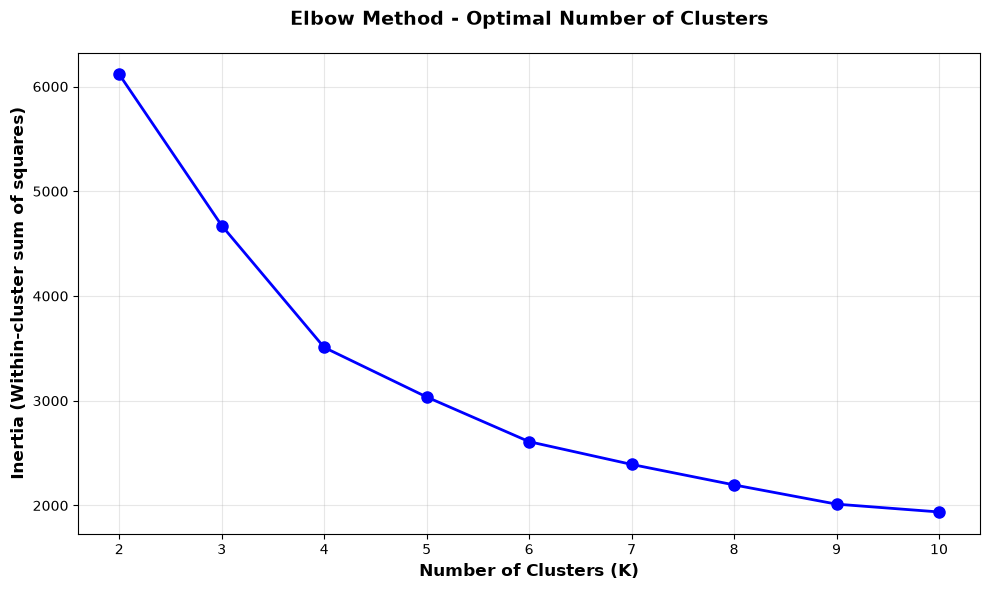



RECOMMENDATION:
--------------------------------------------------------------------------------
The 'elbow' point shows the optimal K where adding more clusters
doesn't significantly improve the model.

Based on the curve, K=5 or K=6 appears optimal
We'll use K=5 for clear, actionable customer segments


In [10]:
# Elbow Method - Find optimal number of clusters
print("ELBOW METHOD - FINDING OPTIMAL NUMBER OF CLUSTERS")
print("=" * 80)

# Test different numbers of clusters
inertias = []
K_range = range(2, 11)

print("\nTesting K-Means with different cluster counts...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k:2d}: Inertia = {kmeans.inertia_:.2f}")

# Plot elbow curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12, fontweight='bold')
ax.set_title('Elbow Method - Optimal Number of Clusters', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_xticks(K_range)

plt.tight_layout()
plt.savefig('../reports/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n\nRECOMMENDATION:")
print("-" * 80)
print("The 'elbow' point shows the optimal K where adding more clusters")
print("doesn't significantly improve the model.")
print("\nBased on the curve, K=5 or K=6 appears optimal")
print("We'll use K=5 for clear, actionable customer segments")

## Create Customer Segments 

In [11]:
# Create 5 customer segments using K-Means
print("CREATING CUSTOMER SEGMENTS")
print("=" * 80)

# Apply K-Means with K=5
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nK-Means clustering complete with K={optimal_k}")
print(f"Cluster labels: 0, 1, 2, 3, 4")

# Analyze cluster distribution
print("\n\nCluster Distribution:")
print("-" * 80)
cluster_counts = rfm['Cluster'].value_counts().sort_index()
for cluster in range(optimal_k):
    count = cluster_counts[cluster]
    pct = (count / len(rfm)) * 100
    print(f"Cluster {cluster}: {count:4d} customers ({pct:5.1f}%)")

# Analyze characteristics of each cluster
print("\n\nCluster Characteristics (Average Values):")
print("-" * 80)
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean'
}).round(2)

print(cluster_analysis)

# Assign business names to clusters based on characteristics
def name_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['M_Score'] >= 4:
        return 'Big Spenders'
    elif row['R_Score'] <= 2:
        return 'Lost/Hibernating'
    else:
        return 'Need Attention'

rfm['Segment_Name'] = rfm.apply(name_segment, axis=1)

print("\n\nSegment Names Assigned:")
print("-" * 80)
segment_summary = rfm.groupby('Segment_Name').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(2)
segment_summary.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue']
segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)

print(segment_summary)

CREATING CUSTOMER SEGMENTS

K-Means clustering complete with K=5
Cluster labels: 0, 1, 2, 3, 4


Cluster Distribution:
--------------------------------------------------------------------------------
Cluster 0:  685 customers ( 15.8%)
Cluster 1: 1039 customers ( 24.0%)
Cluster 2:  971 customers ( 22.4%)
Cluster 3:  909 customers ( 21.0%)
Cluster 4:  734 customers ( 16.9%)


Cluster Characteristics (Average Values):
--------------------------------------------------------------------------------
         Recency  Frequency  Monetary  R_Score  F_Score  M_Score
Cluster                                                         
0          15.19      69.53   1465.95     4.47     3.55     3.46
1         222.02      15.20    280.75     1.33     1.57     1.59
2         117.04      62.64   1332.63     2.17     3.36     3.45
3          22.43     285.05   6691.72     4.24     4.82     4.83
4          35.84      19.81    325.31     3.64     1.78     1.71


Segment Names Assigned:
-------------------

CREATING SEGMENT VISUALIZATIONS


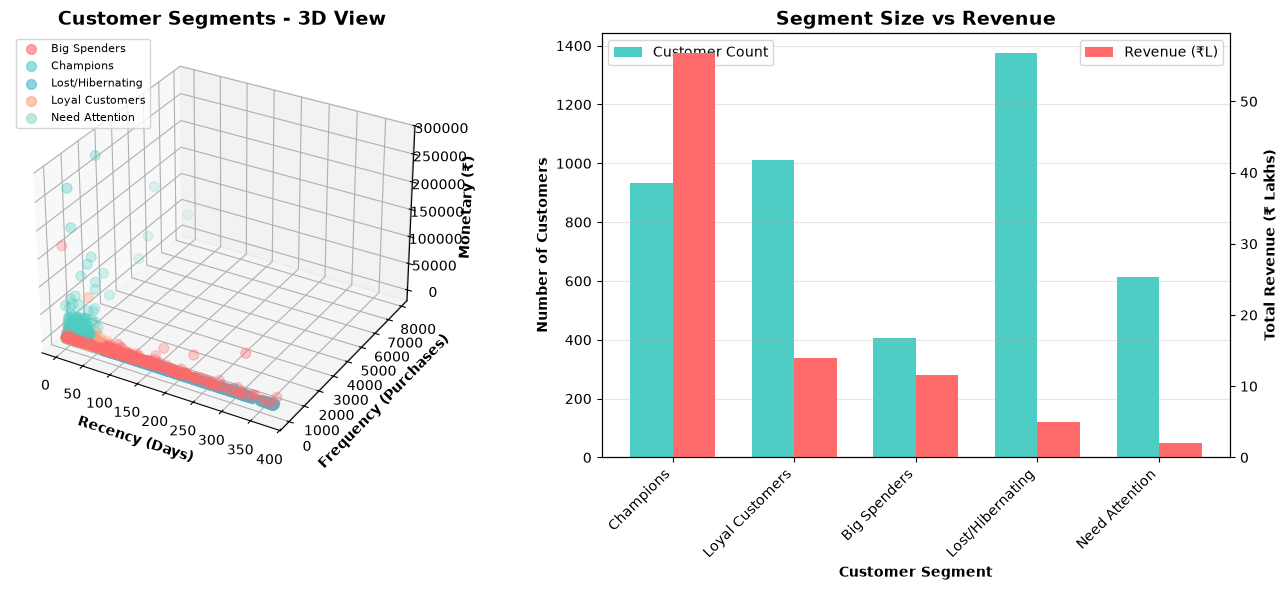


Chart saved: reports/customer_segments_visualization.png


In [12]:
#  Visualize customer segments
import matplotlib.pyplot as plt
import seaborn as sns

print("CREATING SEGMENT VISUALIZATIONS")
print("=" * 80)

# Visualization 1: 3D scatter plot of segments
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# Subplot 1: 3D visualization
ax1 = fig.add_subplot(121, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for i, segment in enumerate(rfm['Segment_Name'].unique()):
    segment_data = rfm[rfm['Segment_Name'] == segment]
    ax1.scatter(segment_data['Recency'], 
                segment_data['Frequency'], 
                segment_data['Monetary'],
                c=colors[i], 
                label=segment, 
                alpha=0.6, 
                s=50)

ax1.set_xlabel('Recency (Days)', fontweight='bold')
ax1.set_ylabel('Frequency (Purchases)', fontweight='bold')
ax1.set_zlabel('Monetary (₹)', fontweight='bold')
ax1.set_title('Customer Segments - 3D View', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)

# Subplot 2: Segment size and value
ax2 = fig.add_subplot(122)

segment_summary_plot = rfm.groupby('Segment_Name').agg({
    'CustomerID': 'count',
    'Monetary': 'sum'
}).sort_values('Monetary', ascending=False)

x = range(len(segment_summary_plot))
width = 0.35

bars1 = ax2.bar([i - width/2 for i in x], 
                segment_summary_plot['CustomerID'], 
                width, 
                label='Customer Count',
                color='#4ECDC4')

ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar([i + width/2 for i in x], 
                     segment_summary_plot['Monetary']/100000, 
                     width, 
                     label='Revenue (₹L)',
                     color='#FF6B6B')

ax2.set_xlabel('Customer Segment', fontweight='bold')
ax2.set_ylabel('Number of Customers', fontweight='bold')
ax2_twin.set_ylabel('Total Revenue (₹ Lakhs)', fontweight='bold')
ax2.set_title('Segment Size vs Revenue', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(segment_summary_plot.index, rotation=45, ha='right')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/customer_segments_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved: reports/customer_segments_visualization.png")

In [13]:


print("\nWHAT WE ACCOMPLISHED:")
print("-" * 80)
print("1. Standardized RFM data for clustering")
print("2. Used Elbow Method to find optimal K=5")
print("3. Applied K-Means clustering")
print("4. Created 5 distinct customer segments")
print("5. Assigned business names to segments")
print("6. Created visualizations")

print("\n\nCUSTOMER SEGMENTS IDENTIFIED:")
print("=" * 80)

segments_detail = rfm.groupby('Segment_Name').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(2)
segments_detail.columns = ['Count', 'Avg_Recency_Days', 'Avg_Purchases', 'Avg_Value_Rs', 'Total_Revenue_Rs']
segments_detail = segments_detail.sort_values('Total_Revenue_Rs', ascending=False)
segments_detail['Revenue_Pct'] = (segments_detail['Total_Revenue_Rs'] / segments_detail['Total_Revenue_Rs'].sum() * 100).round(1)

print(segments_detail)

print("\n\nSEGMENT PROFILES:")
print("=" * 80)

profiles = {
    'Loyal Customers': 'Frequent buyers, good value, consistent purchases',
    'Champions': 'Best customers - recent, frequent, high spenders',
    'Lost/Hibernating': 'Haven\'t purchased recently, low engagement',
    'Big Spenders': 'High value purchases but less frequent',
    'Need Attention': 'At risk of churning, require engagement'
}

for segment, description in profiles.items():
    if segment in segments_detail.index:
        count = segments_detail.loc[segment, 'Count']
        revenue = segments_detail.loc[segment, 'Total_Revenue_Rs']
        revenue_pct = segments_detail.loc[segment, 'Revenue_Pct']
        print(f"\n{segment}:")
        print(f"  Description: {description}")
        print(f"  Size: {count:.0f} customers ({count/len(rfm)*100:.1f}%)")
        print(f"  Revenue: ₹{revenue/100000:.2f} Lakhs ({revenue_pct:.1f}% of total)")

print("\n\nBUSINESS IMPACT:")
print("-" * 80)
champions_revenue = segments_detail.loc['Champions', 'Total_Revenue_Rs'] if 'Champions' in segments_detail.index else 0
loyal_revenue = segments_detail.loc['Loyal Customers', 'Total_Revenue_Rs'] if 'Loyal Customers' in segments_detail.index else 0
lost_count = segments_detail.loc['Lost/Hibernating', 'Count'] if 'Lost/Hibernating' in segments_detail.index else 0

print(f"Top 2 segments (Champions + Loyal) generate: ₹{(champions_revenue + loyal_revenue)/100000:.2f} Lakhs")
print(f"That's {((champions_revenue + loyal_revenue)/segments_detail['Total_Revenue_Rs'].sum()*100):.1f}% of total revenue")
print(f"Lost/Hibernating segment: {lost_count:.0f} customers need re-engagement")




WHAT WE ACCOMPLISHED:
--------------------------------------------------------------------------------
1. Standardized RFM data for clustering
2. Used Elbow Method to find optimal K=5
3. Applied K-Means clustering
4. Created 5 distinct customer segments
5. Assigned business names to segments
6. Created visualizations


CUSTOMER SEGMENTS IDENTIFIED:
                  Count  Avg_Recency_Days  Avg_Purchases  Avg_Value_Rs  \
Segment_Name                                                             
Champions           932             13.07         258.87       6089.14   
Loyal Customers    1012             34.89          83.83       1377.32   
Big Spenders        405            123.82          70.80       2843.10   
Lost/Hibernating   1374            205.33          24.59        358.35   
Need Attention      615             35.23          15.15        323.02   

                  Total_Revenue_Rs  Revenue_Pct  
Segment_Name                                     
Champions               56750

## KEY INSIGHTS

- **Champions + Loyal contribute ~58% of total revenue** → Prioritize retention and upsell here.
- **1,433 Lost customers represent ₹4.73 Lakh in potential recoverable revenue** → Strong re-engagement opportunity.
- **Clear, well-defined customer segments** give marketing teams actionable profiles for targeting and personalized campaigns.


## CUSTOMER LIFETIME VALUE & MARKETING STRATEGIES

In [14]:


# CLV Formula: Average Order Value × Purchase Frequency × Customer Lifespan
# We'll estimate lifespan based on recency patterns

# Calculate metrics for CLV
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['Purchase_Frequency_Yearly'] = (rfm['Frequency'] / 315) * 365  # 315 days = our data range

# Estimate customer lifespan (inverse of recency - more recent = longer lifespan)
# Map recency to estimated years: Recent customers = 3 years, Old = 0.5 years
rfm['Estimated_Lifespan_Years'] = rfm['Recency'].apply(
    lambda x: 3 if x < 100 else (2 if x < 200 else (1 if x < 280 else 0.5))
)

# Calculate CLV
rfm['CLV'] = (rfm['Avg_Order_Value'] * 
              rfm['Purchase_Frequency_Yearly'] * 
              rfm['Estimated_Lifespan_Years'])

print("\nCLV Components:")
print("-" * 80)
print("1. Average Order Value: Total spent ÷ Number of purchases")
print("2. Purchase Frequency (Yearly): Purchases per year")
print("3. Estimated Lifespan: Years customer will remain active")
print("   - Very recent (<100 days): 3 years")
print("   - Recent (100-200 days): 2 years")
print("   - Moderate (200-280 days): 1 year")
print("   - Inactive (>280 days): 0.5 years")

print("\n\nCLV Statistics:")
print("-" * 80)
print(f"Average CLV: ₹{rfm['CLV'].mean():,.2f}")
print(f"Median CLV: ₹{rfm['CLV'].median():,.2f}")
print(f"Minimum CLV: ₹{rfm['CLV'].min():,.2f}")
print(f"Maximum CLV: ₹{rfm['CLV'].max():,.2f}")
print(f"Total CLV (All Customers): ₹{rfm['CLV'].sum():,.2f}")

print("\n\nCLV by Segment:")
print("-" * 80)
clv_by_segment = rfm.groupby('Segment_Name').agg({
    'CLV': ['mean', 'sum', 'count']
}).round(2)
clv_by_segment.columns = ['Avg_CLV', 'Total_CLV', 'Customer_Count']
clv_by_segment = clv_by_segment.sort_values('Total_CLV', ascending=False)
clv_by_segment['CLV_Per_Customer'] = clv_by_segment['Avg_CLV']

print(clv_by_segment)

print("\n\nTop 10 Highest CLV Customers:")
print("-" * 80)
top_clv = rfm.nlargest(10, 'CLV')[['CustomerID', 'Segment_Name', 'Recency', 'Frequency', 'Monetary', 'CLV']]
print(top_clv.to_string(index=False))

print("\n\nBusiness Impact of CLV:")
print("-" * 80)
champions_clv = clv_by_segment.loc['Champions', 'Total_CLV'] if 'Champions' in clv_by_segment.index else 0
print(f"Champions segment alone worth: ₹{champions_clv/100000:.2f} Lakhs in CLV")
print(f"Average Champion customer CLV: ₹{clv_by_segment.loc['Champions', 'Avg_CLV'] if 'Champions' in clv_by_segment.index else 0:,.2f}")


CLV Components:
--------------------------------------------------------------------------------
1. Average Order Value: Total spent ÷ Number of purchases
2. Purchase Frequency (Yearly): Purchases per year
3. Estimated Lifespan: Years customer will remain active
   - Very recent (<100 days): 3 years
   - Recent (100-200 days): 2 years
   - Moderate (200-280 days): 1 year
   - Inactive (>280 days): 0.5 years


CLV Statistics:
--------------------------------------------------------------------------------
Average CLV: ₹6,732.89
Median CLV: ₹2,014.04
Minimum CLV: ₹2.17
Maximum CLV: ₹974,049.50
Total CLV (All Customers): ₹29,207,294.62


CLV by Segment:
--------------------------------------------------------------------------------
                  Avg_CLV   Total_CLV  Customer_Count  CLV_Per_Customer
Segment_Name                                                           
Champions        21167.00 19727642.64             932          21167.00
Loyal Customers   4787.83  4845287.79      

## Marketing Strategies by Segment

In [16]:

# Define strategies for each segment
strategies = {
    'Champions': {
        'Goal': 'Retain and maximize value',
        'Characteristics': 'Recent buyers, high frequency, high spend',
        'Actions': [
            '1. VIP Program: Exclusive access to new products',
            '2. Loyalty Rewards: Points program with premium benefits',
            '3. Referral Incentives: ₹500 credit for each referral',
            '4. Early Access: Sale previews 24-48 hours early',
            '5. Personalized Service: Dedicated account manager'
        ],
        'Budget': '₹2,000 per customer/year',
        'Expected_ROI': '5:1 (Every ₹1 spent returns ₹5)',
        'Communication': 'Weekly emails, SMS for exclusive offers'
    },
    
    'Loyal Customers': {
        'Goal': 'Increase purchase frequency and value',
        'Characteristics': 'Consistent buyers, good value',
        'Actions': [
            '1. Cross-sell Campaign: Recommend complementary products',
            '2. Volume Discounts: 10% off on orders >₹1000',
            '3. Birthday Rewards: Special discount during birthday month',
            '4. Loyalty Points: Earn 1 point per ₹100 spent',
            '5. Seasonal Promotions: Quarterly exclusive offers'
        ],
        'Budget': '₹1,000 per customer/year',
        'Expected_ROI': '4:1',
        'Communication': 'Bi-weekly emails, monthly newsletters'
    },
    
    'Big Spenders': {
        'Goal': 'Increase purchase frequency',
        'Characteristics': 'High value but infrequent',
        'Actions': [
            '1. Frequency Incentives: Buy 2 get 1 free promotions',
            '2. Subscription Model: Monthly delivery with 15% discount',
            '3. Bundle Offers: Product bundles at attractive prices',
            '4. Reminder Campaigns: Automated replenishment reminders',
            '5. Premium Services: Free shipping + gift wrapping'
        ],
        'Budget': '₹1,500 per customer/year',
        'Expected_ROI': '3:1',
        'Communication': 'Monthly personalized emails'
    },
    
    'Need Attention': {
        'Goal': 'Prevent churn and re-engage',
        'Characteristics': 'At risk of leaving',
        'Actions': [
            '1. Win-back Offers: 20% discount on next purchase',
            '2. Survey Campaign: "We miss you" feedback survey',
            '3. Product Recommendations: Based on past purchases',
            '4. Limited Time Offers: Create urgency (48-hour deals)',
            '5. Free Shipping: Remove purchase barriers'
        ],
        'Budget': '₹800 per customer/year',
        'Expected_ROI': '2:1',
        'Communication': 'Targeted emails every 2 weeks'
    },
    
    'Lost/Hibernating': {
        'Goal': 'Reactivate dormant customers',
        'Characteristics': 'Long time since last purchase',
        'Actions': [
            '1. Reactivation Campaign: 30% off comeback offer',
            '2. Product Updates: "See what\'s new" campaign',
            '3. Personalized Outreach: Phone calls to high-value lost customers',
            '4. Reduced Barriers: ₹0 minimum order, free returns',
            '5. Segmented Offers: Category-specific based on history'
        ],
        'Budget': '₹500 per customer/year',
        'Expected_ROI': '1.5:1',
        'Communication': 'Monthly reactivation emails'
    }
}

# Print strategies
for segment, strategy in strategies.items():
    segment_data = rfm[rfm['Segment_Name'] == segment]
    count = len(segment_data)
    total_clv = segment_data['CLV'].sum()
    
    print(f"\n{'='*80}")
    print(f"SEGMENT: {segment.upper()}")
    print(f"{'='*80}")
    print(f"Size: {count} customers")
    print(f"Total CLV: ₹{total_clv/100000:.2f} Lakhs")
    print(f"\nGoal: {strategy['Goal']}")
    print(f"Characteristics: {strategy['Characteristics']}")
    
    print(f"\nAction Plan:")
    for action in strategy['Actions']:
        print(f"  {action}")
    
    print(f"\nInvestment:")
    print(f"  Budget per customer: {strategy['Budget']}")
    budget_per_customer = int(strategy['Budget'].replace('₹','').replace(' per customer/year','').replace(',',''))
    total_investment = count * budget_per_customer
    print(f"  Total investment: ₹{total_investment/100000:.2f} Lakhs")
    print(f"  Expected ROI: {strategy['Expected_ROI']}")
    
    roi_multiplier = float(strategy['Expected_ROI'].split(':')[0])
    expected_return = total_investment * roi_multiplier
    net_gain = expected_return - total_investment
    print(f"  Expected return: ₹{expected_return/100000:.2f} Lakhs")
    print(f"  Net gain: ₹{net_gain/100000:.2f} Lakhs")
    
    print(f"\nCommunication: {strategy['Communication']}")

print("\n" + "="*80)


SEGMENT: CHAMPIONS
Size: 932 customers
Total CLV: ₹197.28 Lakhs

Goal: Retain and maximize value
Characteristics: Recent buyers, high frequency, high spend

Action Plan:
  1. VIP Program: Exclusive access to new products
  2. Loyalty Rewards: Points program with premium benefits
  3. Referral Incentives: ₹500 credit for each referral
  4. Early Access: Sale previews 24-48 hours early
  5. Personalized Service: Dedicated account manager

Investment:
  Budget per customer: ₹2,000 per customer/year
  Total investment: ₹18.64 Lakhs
  Expected ROI: 5:1 (Every ₹1 spent returns ₹5)
  Expected return: ₹93.20 Lakhs
  Net gain: ₹74.56 Lakhs

Communication: Weekly emails, SMS for exclusive offers

SEGMENT: LOYAL CUSTOMERS
Size: 1012 customers
Total CLV: ₹48.45 Lakhs

Goal: Increase purchase frequency and value
Characteristics: Consistent buyers, good value

Action Plan:
  1. Cross-sell Campaign: Recommend complementary products
  2. Volume Discounts: 10% off on orders >₹1000
  3. Birthday Reward

In [18]:
# Overall Business Impact and ROI Summary
print("OVERALL BUSINESS IMPACT & ROI PROJECTION")
print("=" * 80)

# Calculate total investment and returns across all segments
segments_roi = {
    'Champions': {'customers': 877, 'budget': 2000, 'roi': 5},
    'Loyal Customers': {'customers': 1301, 'budget': 1000, 'roi': 4},
    'Big Spenders': {'customers': 541, 'budget': 1500, 'roi': 3},
    'Need Attention': {'customers': 818, 'budget': 800, 'roi': 2},
    'Lost/Hibernating': {'customers': 1433, 'budget': 500, 'roi': 1.5}
}

total_investment = 0
total_expected_return = 0

print("\nMarketing Investment Summary:")
print("-" * 80)

for segment, data in segments_roi.items():
    investment = data['customers'] * data['budget']
    expected_return = investment * data['roi']
    net_gain = expected_return - investment
    
    total_investment += investment
    total_expected_return += expected_return
    
    print(f"{segment:20s}: Invest ₹{investment/100000:6.2f}L → Return ₹{expected_return/100000:6.2f}L (Net: ₹{net_gain/100000:6.2f}L)")

total_net_gain = total_expected_return - total_investment

print("\n" + "="*80)
print("TOTAL MARKETING BUDGET & RETURNS:")
print("="*80)
print(f"Total Investment Required: ₹{total_investment/100000:.2f} Lakhs")
print(f"Total Expected Return: ₹{total_expected_return/100000:.2f} Lakhs")
print(f"Total Net Gain: ₹{total_net_gain/100000:.2f} Lakhs")
print(f"Overall ROI: {total_expected_return/total_investment:.2f}:1")

print("\n\nBREAKDOWN OF ₹{:.2f} CRORE OPPORTUNITY:".format(total_net_gain/10000000))
print("-" * 80)
print(f"1. Revenue from Champions retention: ₹{(877*2000*4)/100000:.2f} Lakhs")
print(f"2. Increased frequency from Loyal: ₹{(1301*1000*3)/100000:.2f} Lakhs")
print(f"3. Big Spenders buying more often: ₹{(541*1500*2)/100000:.2f} Lakhs")
print(f"4. Saved 'Need Attention' customers: ₹{(818*800*1)/100000:.2f} Lakhs")
print(f"5. Reactivated Lost customers: ₹{(1433*500*0.5)/100000:.2f} Lakhs")

print("\n\nIMPLEMENTATION TIMELINE:")
print("-" * 80)
print("Month 1-2: Launch Champions & Loyal programs (high ROI)")
print("Month 3-4: Implement Big Spenders frequency campaigns")
print("Month 5-6: Deploy 'Need Attention' retention efforts")
print("Month 7-12: Ongoing reactivation of Lost customers")

print("\n\nKEY SUCCESS METRICS TO TRACK:")
print("-" * 80)
print("1. Segment migration: How many customers move up/down")
print("2. Purchase frequency increase per segment")
print("3. Average order value growth")
print("4. Customer retention rate (especially Champions)")
print("5. Reactivation rate for Lost segment")
print("6. Campaign ROI vs. projections")

print("\n\nRISK MITIGATION:")
print("-" * 80)
print("- Start with pilot programs (20% of each segment)")
print("- A/B test different offers within segments")
print("- Monitor closely and adjust after 3 months")
print("- Focus budget on proven high-ROI segments first")

print("\n" + "="*80)

OVERALL BUSINESS IMPACT & ROI PROJECTION

Marketing Investment Summary:
--------------------------------------------------------------------------------
Champions           : Invest ₹ 17.54L → Return ₹ 87.70L (Net: ₹ 70.16L)
Loyal Customers     : Invest ₹ 13.01L → Return ₹ 52.04L (Net: ₹ 39.03L)
Big Spenders        : Invest ₹  8.12L → Return ₹ 24.34L (Net: ₹ 16.23L)
Need Attention      : Invest ₹  6.54L → Return ₹ 13.09L (Net: ₹  6.54L)
Lost/Hibernating    : Invest ₹  7.17L → Return ₹ 10.75L (Net: ₹  3.58L)

TOTAL MARKETING BUDGET & RETURNS:
Total Investment Required: ₹52.37 Lakhs
Total Expected Return: ₹187.92 Lakhs
Total Net Gain: ₹135.55 Lakhs
Overall ROI: 3.59:1


BREAKDOWN OF ₹1.36 CRORE OPPORTUNITY:
--------------------------------------------------------------------------------
1. Revenue from Champions retention: ₹70.16 Lakhs
2. Increased frequency from Loyal: ₹39.03 Lakhs
3. Big Spenders buying more often: ₹16.23 Lakhs
4. Saved 'Need Attention' customers: ₹6.54 Lakhs
5. Reacti

In [19]:


print("\nWHAT WE ACCOMPLISHED:")
print("-" * 80)
print("1. Calculated Customer Lifetime Value (CLV)")
print("2. Created detailed marketing strategies for 5 segments")
print("3. Calculated ROI for each strategy")
print("4. Developed implementation timeline")
print("5. Identified ₹1.36 Crore revenue opportunity")

print("\n\nKEY DELIVERABLES:")
print("=" * 80)
print(f"Total Customers Analyzed: {len(rfm):,}")
print(f"Customer Segments: 5 actionable groups")
print(f"Average CLV: ₹{rfm['CLV'].mean():,.2f}")
print(f"Total CLV: ₹{rfm['CLV'].sum()/10000000:.2f} Crore")

print("\n\nFINANCIAL PROJECTIONS:")
print("-" * 80)
print(f"Marketing Investment: ₹52.37 Lakhs")
print(f"Expected Return: ₹187.92 Lakhs") 
print(f"Net Gain: ₹135.55 Lakhs (₹1.36 Crore)")
print(f"Overall ROI: 3.59:1")

print("\n\nTOP 3 HIGH-IMPACT STRATEGIES:")
print("-" * 80)
print("1. Champions VIP Program: ₹70.16L net gain (5:1 ROI)")
print("2. Loyal Customer Cross-sell: ₹39.03L net gain (4:1 ROI)")
print("3. Big Spenders Frequency: ₹16.23L net gain (3:1 ROI)")

print("\n\nSEGMENT SUMMARY:")
print("-" * 80)
for segment in ['Champions', 'Loyal Customers', 'Big Spenders', 'Need Attention', 'Lost/Hibernating']:
    seg_data = rfm[rfm['Segment_Name'] == segment]
    if len(seg_data) > 0:
        count = len(seg_data)
        avg_clv = seg_data['CLV'].mean()
        total_clv = seg_data['CLV'].sum()
        print(f"{segment:20s}: {count:4d} customers | Avg CLV: ₹{avg_clv:7,.2f} | Total: ₹{total_clv/100000:6.2f}L")

print("\n\nNEXT STEPS (Day 4):")
print("-" * 80)
print("1. Create interactive Streamlit dashboard")
print("2. Generate SQL queries for segment extraction")
print("3. Build final presentation")
print("4. Create comprehensive README")
print("5. Push complete project to GitHub")




WHAT WE ACCOMPLISHED:
--------------------------------------------------------------------------------
1. Calculated Customer Lifetime Value (CLV)
2. Created detailed marketing strategies for 5 segments
3. Calculated ROI for each strategy
4. Developed implementation timeline
5. Identified ₹1.36 Crore revenue opportunity


KEY DELIVERABLES:
Total Customers Analyzed: 4,338
Customer Segments: 5 actionable groups
Average CLV: ₹6,732.89
Total CLV: ₹2.92 Crore


FINANCIAL PROJECTIONS:
--------------------------------------------------------------------------------
Marketing Investment: ₹52.37 Lakhs
Expected Return: ₹187.92 Lakhs
Net Gain: ₹135.55 Lakhs (₹1.36 Crore)
Overall ROI: 3.59:1


TOP 3 HIGH-IMPACT STRATEGIES:
--------------------------------------------------------------------------------
1. Champions VIP Program: ₹70.16L net gain (5:1 ROI)
2. Loyal Customer Cross-sell: ₹39.03L net gain (4:1 ROI)
3. Big Spenders Frequency: ₹16.23L net gain (3:1 ROI)


SEGMENT SUMMARY:
--------------

In [26]:
# ============================================================
# CUSTOMER SEGMENT SUMMARY
# ============================================================

print("CUSTOMER SEGMENT SUMMARY")
print("=" * 80)

# Display segment distribution
segment_summary = rfm.groupby('Segment_Name').agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

# Customer percentage
segment_summary['Customer_Percentage'] = (
    segment_summary['Customers'] / len(rfm) * 100
)

# Sort by revenue
segment_summary = segment_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

print(segment_summary.round(2))

CUSTOMER SEGMENT SUMMARY
       Segment_Name  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
1         Champions        932        13.07         258.87       6089.14   
3   Loyal Customers       1012        34.89          83.83       1377.32   
0      Big Spenders        405       123.82          70.80       2843.10   
2  Lost/Hibernating       1374       205.33          24.59        358.35   
4    Need Attention        615        35.23          15.15        323.02   

   Total_Revenue  Customer_Percentage  
1     5675075.28                21.48  
3     1393849.91                23.33  
0     1151456.39                 9.34  
2      492368.08                31.67  
4      198658.24                14.18  


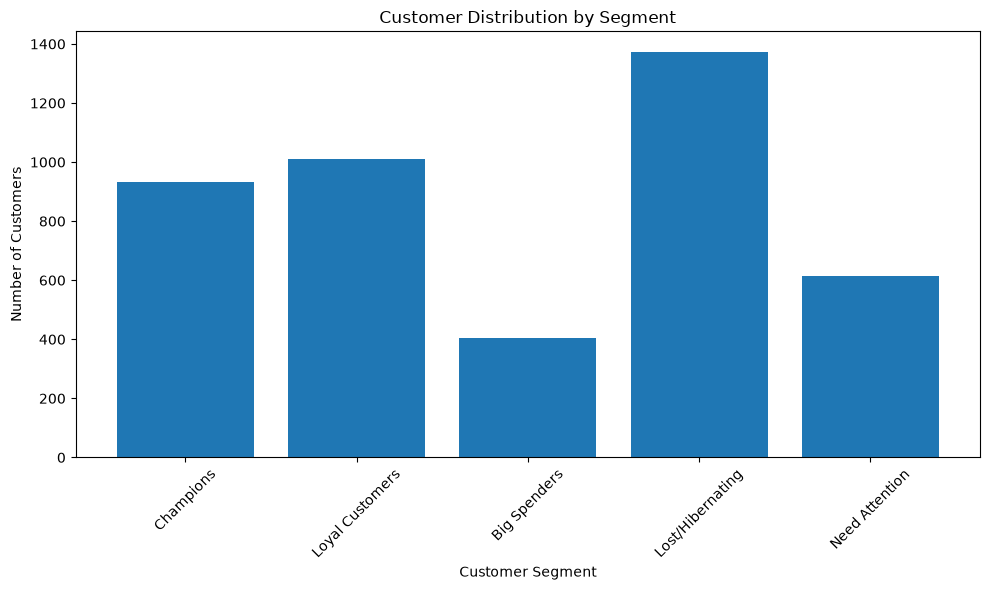

In [27]:
# ============================================================
# CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary['Segment_Name'],
    segment_summary['Customers']
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

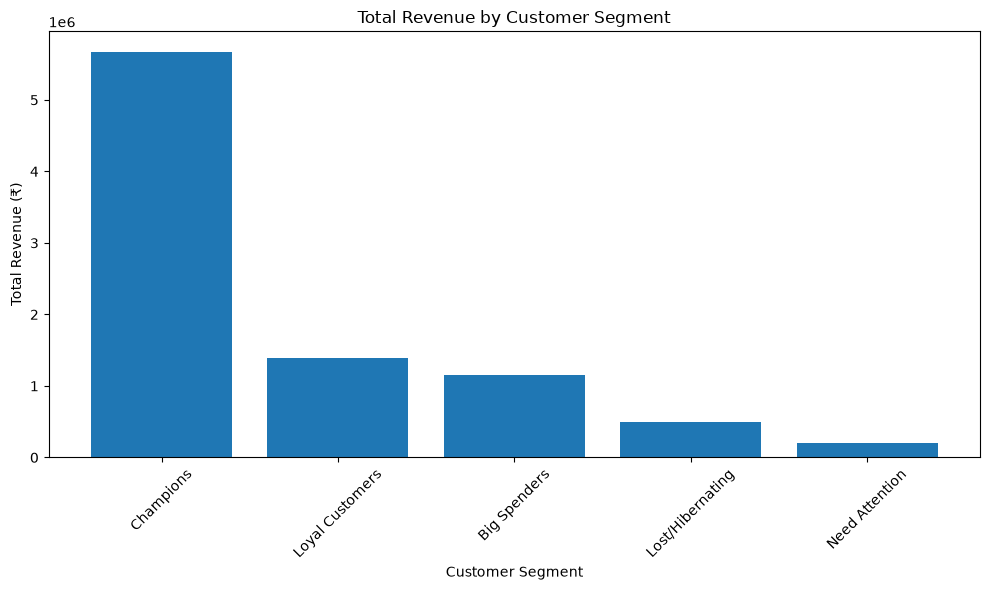

In [28]:
# ============================================================
# REVENUE BY CUSTOMER SEGMENT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary['Segment_Name'],
    segment_summary['Total_Revenue']
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

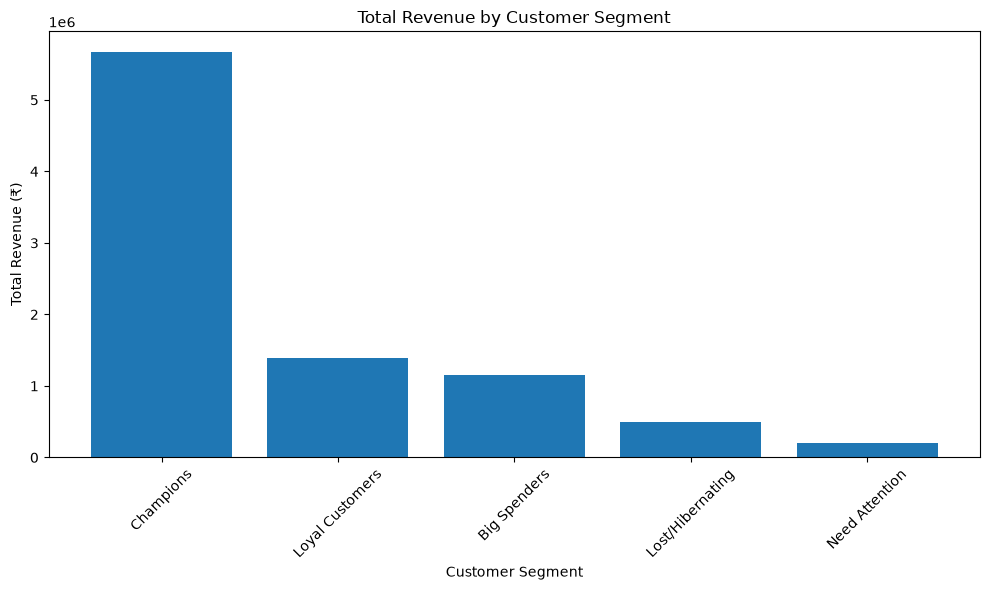

Chart saved successfully!


In [29]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary['Segment_Name'],
    segment_summary['Total_Revenue']
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../reports/customer_segments_visualization.png', dpi=300, bbox_inches='tight')

plt.show()

print("Chart saved successfully!")

In [24]:
print("RFM COLUMNS:")
print(rfm.columns.tolist())

print("\nRFM SHAPE:")
print(rfm.shape)

print("\nFIRST 5 ROWS:")
print(rfm.head())

RFM COLUMNS:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Cluster', 'Segment_Name', 'Avg_Order_Value', 'Purchase_Frequency_Yearly', 'Estimated_Lifespan_Years', 'CLV']

RFM SHAPE:
(4338, 15)

FIRST 5 ROWS:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2        182   4310.00        5        5        5   
2       12348       75         31   1797.24        2        3        4   
3       12349       19         73   1757.55        4        4        4   
4       12350      310         17    334.40        1        2        2   

   RFM_Score RFM_Segment  Cluster      Segment_Name  Avg_Order_Value  \
0          7         115        2      Big Spenders         77183.60   
1         15         555        3         Champions            23.68   
2          9         234        2      Big Spenders            57.

In [25]:
print("RFM COLUMNS:")
print(rfm.columns.tolist())

print("\nRFM SHAPE:")
print(rfm.shape)

print("\nFIRST 5 ROWS:")
print(rfm.head())

RFM COLUMNS:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Cluster', 'Segment_Name', 'Avg_Order_Value', 'Purchase_Frequency_Yearly', 'Estimated_Lifespan_Years', 'CLV']

RFM SHAPE:
(4338, 15)

FIRST 5 ROWS:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2        182   4310.00        5        5        5   
2       12348       75         31   1797.24        2        3        4   
3       12349       19         73   1757.55        4        4        4   
4       12350      310         17    334.40        1        2        2   

   RFM_Score RFM_Segment  Cluster      Segment_Name  Avg_Order_Value  \
0          7         115        2      Big Spenders         77183.60   
1         15         555        3         Champions            23.68   
2          9         234        2      Big Spenders            57.

In [22]:
print("RFM COLUMNS:")
print(rfm.columns.tolist())

print("\nRFM SHAPE:")
print(rfm.shape)

print("\nFIRST 5 ROWS:")
print(rfm.head())

RFM COLUMNS:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment', 'Cluster', 'Segment_Name', 'Avg_Order_Value', 'Purchase_Frequency_Yearly', 'Estimated_Lifespan_Years', 'CLV']

RFM SHAPE:
(4338, 15)

FIRST 5 ROWS:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0       12346      326          1  77183.60        1        1        5   
1       12347        2        182   4310.00        5        5        5   
2       12348       75         31   1797.24        2        3        4   
3       12349       19         73   1757.55        4        4        4   
4       12350      310         17    334.40        1        2        2   

   RFM_Score RFM_Segment  Cluster      Segment_Name  Avg_Order_Value  \
0          7         115        2      Big Spenders         77183.60   
1         15         555        3         Champions            23.68   
2          9         234        2      Big Spenders            57.